# Escalado y Redución de la dimensionalidad de los datos usando PCA y t-SNE

### Importamos las librerías que vamos a utilizar en esta etapa del trabajo.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from funciones_mecanizados import normalizar
from funciones_mecanizados import cortar
from funciones_mecanizados import pca
from sklearn.manifold import TSNE

### Cargamos los archivos de cada una de las herramientas que previamente fuerón etiquetados cada uno de sus mecanizados. 

In [2]:
h1 = pd.read_csv('data/panel1_H1.csv')
h2 = pd.read_csv('data/panel2_H2.csv')
h3 = pd.read_csv('data/panel1_H3.csv')
h3_ = pd.read_csv('data/panel2_H3.csv')

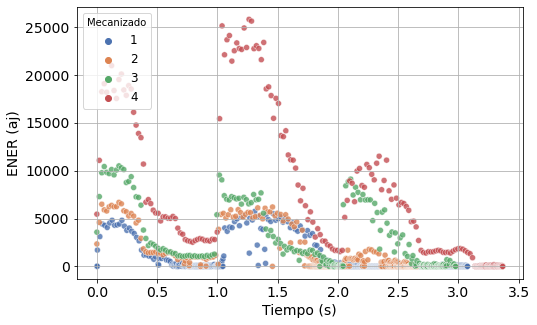

In [3]:
#Plot dataset separado por mecanizados
plt.figure(figsize=(8,5))
var = 'ENER'
ch = 2
data=h3

sns.scatterplot(data=data[data['CH']==ch], x='Tiempo', y=var, hue='Mecanizado', palette='deep', alpha=0.8)
plt.legend(title='Mecanizado', loc=2, fontsize=12)
plt.ylabel('ENER (aj)',fontsize=14)
plt.xlabel('Tiempo (s)',fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.grid('True')

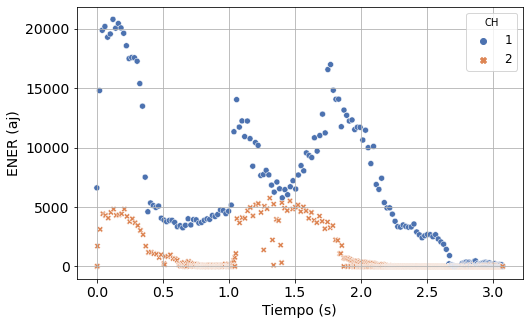

In [4]:
# Visualización de un mecanizado
plt.figure(figsize=(8,5))
var='ENER'
datos = h3
mecanizado = 1

sns.scatterplot(data=datos[datos['Mecanizado']==mecanizado], x='Tiempo', y=var, hue='CH', palette='deep', style="CH")
plt.legend(title='CH', loc=1, fontsize=12)
plt.ylabel('ENER (aj)',fontsize=14)
plt.xlabel('Tiempo (s)',fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
#plt.ylim([0,2000])
plt.grid('True')

### Eliminamos los datos que consideramos como ruido utilizando como referencia la energía.

In [5]:
nivel = 1000

h1.drop(h1[h1['ENER']<nivel].index, axis=0, inplace=True)
h2.drop(h2[h2['ENER']<nivel].index, axis=0, inplace=True)
h3.drop(h3[h3['ENER']<nivel].index, axis=0, inplace=True)
h3_.drop(h3_[h3_['ENER']<nivel].index, axis=0, inplace=True)

### Normalizamos cada uno de los mecanizados.

In [6]:
columnas = ['RMS','AMP','ENER','P_FRQ','PCNTS','C_FRQ', 'I_FRQ','A_FRQ',
            'R_FRQ','DURATION','ASL','COUN','ABS_ENERGY', 'SIG_STRNGTH','RISE']

metodo = 'MinMaxScaler'
h1_norm = normalizar(h1, columnas, metodo)
h2_norm = normalizar(h2, columnas, metodo)
h3_norm = normalizar(h3, columnas, metodo)

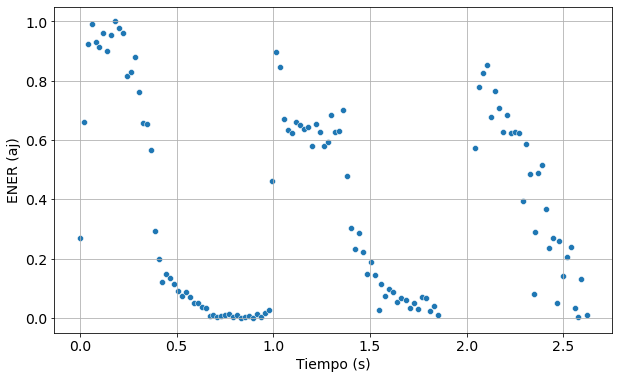

In [7]:
#Plot mecanizados normalizados
plt.figure(figsize=(10,6))
var = 'ENER'
ch = 2
data=h3_norm
mec = 3

sns.scatterplot(data=data[(data['CH']==ch) & (data['Mecanizado']==mec)], x='Tiempo', y=var, palette='deep', alpha=1)
#plt.legend(title='Mecanizado', loc=1, fontsize=12, framealpha=0.7)
plt.ylabel('ENER (aj)',fontsize=14)
plt.xlabel('Tiempo (s)',fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.grid('True')

In [8]:
h1_norm.drop(h1_norm[(h1_norm.Mecanizado==3) & (h1_norm.CH==2)].index, axis=0, inplace=True)
h1_norm.drop(h1_norm[(h1_norm.Mecanizado==4) & (h1_norm.CH==2)].index, axis=0, inplace=True)

### Extraemos los datos que corresponden a la etapa del fresado de cada una de las herramienta.

In [9]:
corte1 = [1,1.4]
corte2 = [2,2.4]

fresado_h1 = pd.concat([cortar(h1_norm, corte1), cortar(h1_norm, corte2)])
fresado_h2 = pd.concat([cortar(h2_norm, corte1), cortar(h2_norm, corte2)])
fresado_h3 = pd.concat([cortar(h3_norm, corte1), cortar(h3_norm, corte2)])

print('H1:',fresado_h1.shape)
print('H2:',fresado_h2.shape)
print('H3:',fresado_h3.shape)

H1: (163, 19)
H2: (350, 19)
H3: (226, 19)


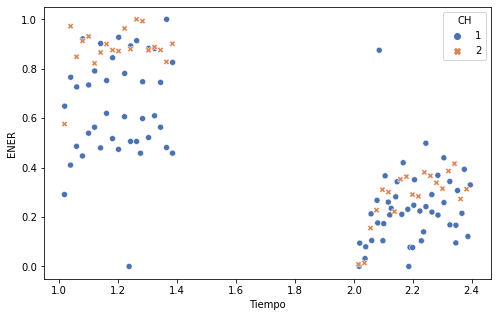

In [10]:
fresado = pd.concat([fresado_h1, fresado_h2, fresado_h3])

# Visualización de un mecanizado
plt.figure(figsize=(8,5))
var='ENER'
datos = fresado
mecanizado = 4

sns.scatterplot(data=datos[datos['Mecanizado']==mecanizado], x='Tiempo', y=var, hue='CH', palette='deep', style="CH")
plt.show()

In [11]:
ix_1 = fresado[(fresado.Tiempo < 1.4) & (fresado.ENER < 0.2) & (fresado.Mecanizado == 4)].index
ix_2 = fresado[(fresado.Tiempo > 1.8) & (fresado.ENER > 0.8) & (fresado.Mecanizado == 4)].index

print(fresado.loc[ix_1].Herramienta)
print(fresado.loc[ix_2].Herramienta)

4946    Nueva
Name: Herramienta, dtype: object
5277    Nueva
Name: Herramienta, dtype: object


In [12]:
#fresado_h3.drop([ix_1[0], ix_2[0]], axis=0, inplace=True)

In [13]:
# guardamos los datos normalizados en un excel para usarlos luego.
fresado_h1.to_csv(r'data/fresado_H1_norm.csv', index=False)
fresado_h2.to_csv(r'data/fresado_H2_norm.csv', index=False)
fresado_h3.to_csv(r'data/fresado_H3_norm.csv', index=False)

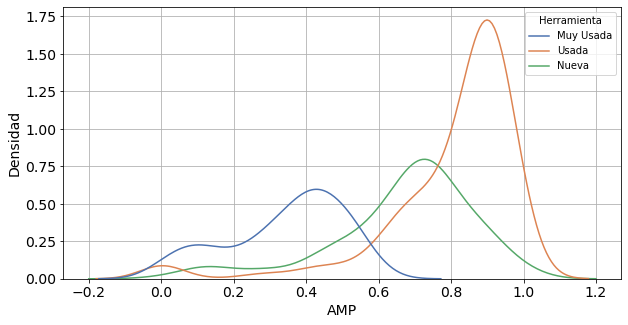

In [14]:
plt.figure(figsize=(10,5))

var = 'AMP'

a = pd.concat([fresado_h1, fresado_h2, fresado_h3])

sns.kdeplot(data= a, x=var, palette='deep', hue='Herramienta', legend=True)

plt.xlabel(var, size=14)
plt.ylabel('Densidad', size=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.grid(True)
plt.show()



### Aplicamos el PCA

In [15]:
cols =  ['RMS','PCNTS','AMP','ENER','C_FRQ', 'I_FRQ','A_FRQ',
         'R_FRQ','ASL','COUN','ABS_ENERGY', 'SIG_STRNGTH', 'RISE', 'P_FRQ','DURATION']


pc_df, pca_model = pca([fresado_h1,fresado_h2,fresado_h3], cols)
PC_name = list(pc_df.columns.drop(['Herramienta','Mecanizado','CH']))

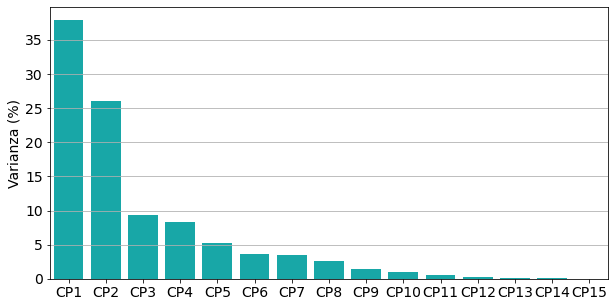

In [16]:
varianza_df = pd.DataFrame({'Varianza':np.round(pca_model.explained_variance_ratio_*100,4), 'CP':PC_name})

plt.figure(figsize=(10,5))

sns.barplot(x='CP', y='Varianza', data=varianza_df, color='c')

plt.xlabel('')
plt.ylabel('Varianza (%)', size=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.grid(True, axis='y')

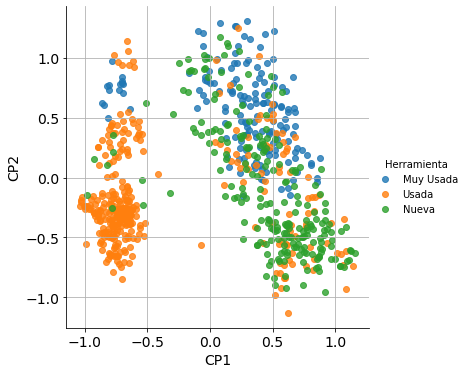

In [17]:
sns.lmplot(x='CP1', y='CP2', data=pc_df, fit_reg=False, hue='Herramienta', legend=True)
plt.ylabel('CP2',fontsize=14)
plt.xlabel('CP1',fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.grid('True')
plt.show()

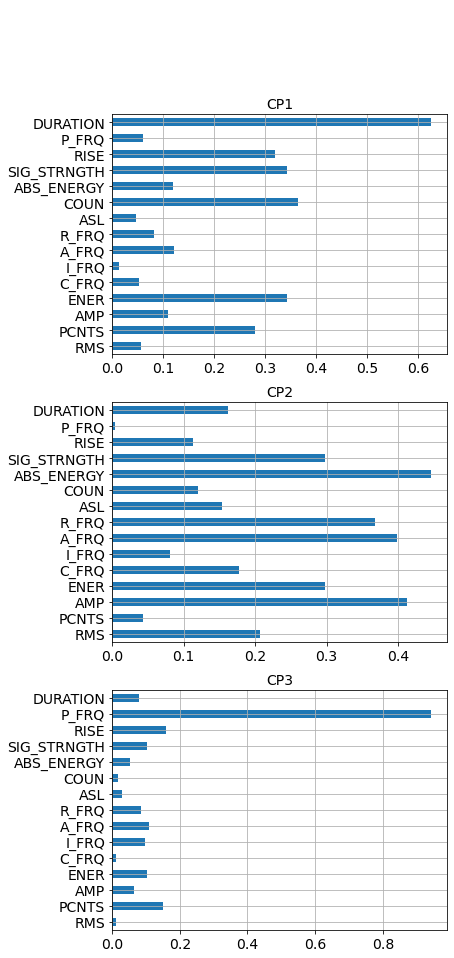

In [18]:
feature_scores = pd.DataFrame(np.round(abs(pca_model.components_),3), columns=cols, index=PC_name)
feature_scores[0:3]


plt.figure(figsize=(6,15))
plt.suptitle(' ', size = 25)


plt.subplot(3,1,1)
plt.title('CP1', size=14)
feature_scores.loc['CP1'].plot.barh()
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.grid(True)


plt.subplot(3,1,2)
plt.title('CP2', size=14)
feature_scores.loc['CP2'].plot.barh()
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.grid(True)


plt.subplot(3,1,3)
plt.title('CP3', size=14)
feature_scores.loc['CP3'].plot.barh()
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.grid(True)

plt.show()

<IPython.core.display.Javascript object>


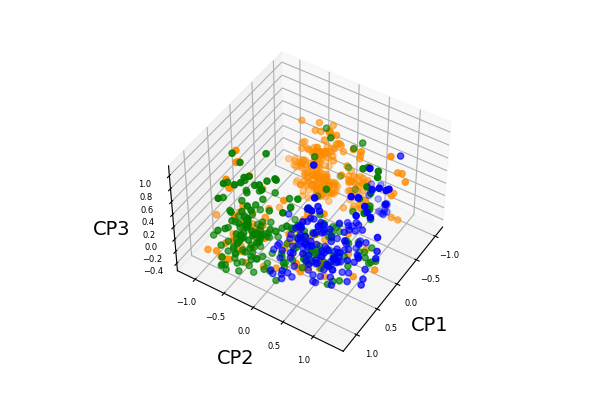

In [23]:
#%%grafica 3d
#%matplotlib notebook
%matplotlib notebook
fig = plt.figure(figsize=(6,4))
ax1 = fig.add_subplot(111, projection='3d')

pc_df_H1 = pc_df[pc_df['Herramienta']=='Muy Usada']
pc_df_H2 = pc_df[pc_df['Herramienta']=='Usada']
pc_df_H3 = pc_df[pc_df['Herramienta']=='Nueva'] 

ax1.scatter(pc_df_H1['CP1'],pc_df_H1['CP2'],pc_df_H1['CP3'], c='b' , marker='o')
ax1.scatter(pc_df_H2['CP1'],pc_df_H2['CP2'],pc_df_H2['CP3'], c='darkorange' , marker='o')
ax1.scatter(pc_df_H3['CP1'],pc_df_H3['CP2'],pc_df_H3['CP3'], c='g' , marker='o')

ax1.tick_params(width=10, labelsize=6, pad=2,labelrotation=0)

ax1.set_xlabel('CP1', fontsize=14)
ax1.set_ylabel('CP2', fontsize=14)
ax1.set_zlabel('CP3', fontsize=14)

plt.show()

### t_SNE

In [26]:
cols =  ['RMS','PCNTS','AMP','ENER','C_FRQ', 'I_FRQ','A_FRQ',
         'R_FRQ','ASL','COUN','ABS_ENERGY', 'SIG_STRNGTH', 'RISE', 'P_FRQ']

X_ = pd.concat([fresado_h1, fresado_h2, fresado_h3])
X_.reset_index(inplace=True)
X_tsne_model = TSNE(perplexity=60, n_components=3, n_iter=4000, random_state=23, learning_rate=200, early_exaggeration=10 )
X_tsne = X_tsne_model.fit_transform(X_[cols])

X_tsne_df = pd.DataFrame(X_tsne)
X_tsne_df['Herramienta'] = X_['Herramienta']
X_tsne_df = X_tsne_df.rename(columns={0:'SNE1', 1:'SNE2', 2:'SNE3'})

<IPython.core.display.Javascript object>


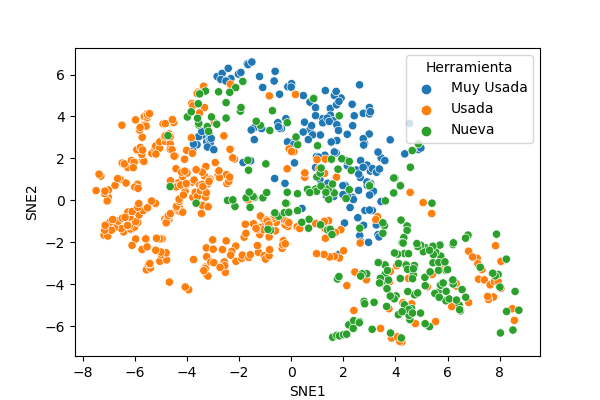

In [27]:
plt.figure(figsize=(6,4))
sns.scatterplot(data=X_tsne_df, x='SNE1', y='SNE2', hue='Herramienta')
plt.show()

In [29]:
#%matplotlib notebook


fig = plt.figure(figsize=(10,6))
ax1 = fig.add_subplot(111, projection='3d')
X_tsne_df_H1 = X_tsne_df[X_tsne_df['Herramienta']=='Muy Usada']
X_tsne_df_H2 = X_tsne_df[X_tsne_df['Herramienta']=='Usada']
X_tsne_df_H3 = X_tsne_df[X_tsne_df['Herramienta']=='Nueva'] 

ax1.scatter(X_tsne_df_H1['SNE1'], X_tsne_df_H1['SNE2'], X_tsne_df_H1['SNE3'], c='b' , marker='o')
ax1.scatter(X_tsne_df_H2['SNE1'], X_tsne_df_H2['SNE2'], X_tsne_df_H2['SNE3'], c='darkorange' , marker='o')
ax1.scatter(X_tsne_df_H3['SNE1'], X_tsne_df_H3['SNE2'], X_tsne_df_H3['SNE3'], c='g' , marker='o')
plt.show()

ax1.set_xlabel('tDNE1', fontsize=14)
ax1.set_ylabel('tDNE2', fontsize=14)
ax1.set_zlabel('tDNE3', fontsize=14)
plt.show()

<IPython.core.display.Javascript object>